# Proposition 3.1 Notebook: RRWP + MLP Recovers Truncated Shortest-Path Distance

This notebook presents a synthetic study of Proposition 3.1(a) from *Graph Inductive Biases in Transformers without Message Passing*.

**Run this notebook from the `base` Conda environment:**

```bash
conda activate base
jupyter lab
```

The notebook focuses on the following setting:

- compute **relative random walk probabilities (RRWP)** on synthetic graphs,
- use the pairwise feature vector $P[i, j, :] = [I, M, \ldots, M^{K-1}]$ for each ordered node pair `(i, j)`,
- train a small **MLP** to predict the **truncated shortest-path distance** between `i` and `j`.

Only **Proposition 3.1(a)** is studied here. The propagation-matrix results from Proposition 3.1(b)/(c) are left for a separate analysis.


In [1]:
# This cell only installs packages that are missing.
import importlib
import subprocess
import sys

PACKAGE_MAP = {
    "torch": "torch",
    "networkx": "networkx",
    "pandas": "pandas",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
}

missing = []
for module_name, package_name in PACKAGE_MAP.items():
    try:
        importlib.import_module(module_name)
    except Exception:
        missing.append(package_name)

if missing:
    print("Installing missing packages:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("All required packages are already installed.")

All required packages are already installed.


In [2]:
CONFIG = {
    "seed": 7,
    "graph_families": ["path", "cycle", "balanced_tree", "grid", "erdos_renyi", "sbm"],
    "graphs_per_split": {"train": 8, "val": 2, "test": 2},
    "node_range": (16, 30),
    "k_main": 6,
    "k_sweep": [2, 4, 6],
    "max_epochs": 80,
    "patience": 10,
    "batch_size": 4096,
    "hidden_dims": [128, 128, 64],
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "walkthrough_family": "grid",
    "walkthrough_shape": (4, 5),
    "family_holdouts": ["grid", "sbm"],
}
CONFIG

{'seed': 7,
 'graph_families': ['path',
  'cycle',
  'balanced_tree',
  'grid',
  'erdos_renyi',
  'sbm'],
 'graphs_per_split': {'train': 8, 'val': 2, 'test': 2},
 'node_range': (16, 30),
 'k_main': 6,
 'k_sweep': [2, 4, 6],
 'max_epochs': 80,
 'patience': 10,
 'batch_size': 4096,
 'hidden_dims': [128, 128, 64],
 'learning_rate': 0.001,
 'weight_decay': 0.0001,
 'walkthrough_family': 'grid',
 'walkthrough_shape': (4, 5),
 'family_holdouts': ['grid', 'sbm']}

In [3]:
import os
import math
import random
from collections import Counter

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (7, 5)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")
if DEVICE == "cuda":
    print(torch.cuda.get_device_name(0))
else:
    print("CUDA is not available")

Using device: cuda
Tesla T4


In [4]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(CONFIG["seed"])

## 1. Theory Framing

For a graph with adjacency matrix `A`, define the row-normalized random-walk matrix

$$
M = D^{-1}A
$$

and the `K`-hop RRWP tensor

$$
P = [I, M, M^2, \dots, M^{K-1}] \in \mathbb{R}^{n \times n \times K}.
$$

For every ordered node pair `(i, j)`, the vector `P[i, j, :]` records the probability of reaching node `j` from node `i` in exactly `0, 1, \ldots, K-1` random-walk steps.

**Proposition 3.1(a)** states that an MLP acting independently on these pairwise vectors can approximate the **truncated shortest-path distance**:

$$
\mathrm{SPD}_{K-1}(i, j) =
\begin{cases}
\mathrm{SPD}(i, j), & \text{if } \mathrm{SPD}(i, j) \le K-1 \\
K, & \text{otherwise.}
\end{cases}
$$

The experimental objective is to test whether RRWP features provide enough multihop information for a small pairwise MLP to recover this truncated distance.


In [5]:
def relabel_graph(G: nx.Graph) -> nx.Graph:
    return nx.convert_node_labels_to_integers(G, ordering="sorted")


def grid_positions(rows: int, cols: int):
    return {(r * cols + c): (c, -r) for r in range(rows) for c in range(cols)}


def build_walkthrough_graph():
    rows, cols = CONFIG["walkthrough_shape"]
    G = nx.grid_2d_graph(rows, cols)
    G = nx.convert_node_labels_to_integers(G, ordering="sorted")
    pos = grid_positions(rows, cols)
    return G, pos


def sample_balanced_tree(rng: np.random.Generator, low: int, high: int) -> nx.Graph:
    target_n = int(rng.integers(max(low, 18), high + 1))
    base = nx.balanced_tree(r=2, h=4)
    bfs_nodes = list(nx.bfs_tree(base, source=0).nodes())[:target_n]
    G = nx.Graph(base.subgraph(bfs_nodes))
    return relabel_graph(G)


def sample_grid(rng: np.random.Generator) -> nx.Graph:
    shapes = [(4, 4), (4, 5), (5, 4), (5, 5), (4, 6), (3, 6), (3, 7)]
    rows, cols = shapes[int(rng.integers(0, len(shapes)))]
    G = nx.grid_2d_graph(rows, cols)
    return relabel_graph(G)


def sample_connected_graph(family: str, rng: np.random.Generator, low: int, high: int) -> nx.Graph:
    if family == "path":
        n = int(rng.integers(low, high + 1))
        return relabel_graph(nx.path_graph(n))
    if family == "cycle":
        n = int(rng.integers(low, high + 1))
        return relabel_graph(nx.cycle_graph(n))
    if family == "balanced_tree":
        return sample_balanced_tree(rng, low, high)
    if family == "grid":
        return sample_grid(rng)

    if family == "erdos_renyi":
        while True:
            n = int(rng.integers(max(low, 18), high + 1))
            p = float(rng.uniform(0.12, 0.25))
            G = nx.erdos_renyi_graph(n=n, p=p, seed=int(rng.integers(1_000_000)))
            if nx.is_connected(G):
                return relabel_graph(G)

    if family == "sbm":
        while True:
            n = int(rng.integers(max(low, 18), high + 1))
            left = int(rng.integers(max(6, n // 3), min(n - 6, 2 * n // 3) + 1))
            sizes = [left, n - left]
            p_in = float(rng.uniform(0.25, 0.40))
            p_out = float(rng.uniform(0.02, 0.08))
            probs = [[p_in, p_out], [p_out, p_in]]
            G = nx.stochastic_block_model(sizes, probs, seed=int(rng.integers(1_000_000)))
            if nx.is_connected(G):
                return relabel_graph(G)

    raise ValueError(f"Unknown family: {family}")


def compute_spd_matrix(G: nx.Graph) -> np.ndarray:
    n = G.number_of_nodes()
    spd = np.zeros((n, n), dtype=np.int64)
    lengths = dict(nx.all_pairs_shortest_path_length(G))
    for i in range(n):
        for j in range(n):
            spd[i, j] = lengths[i][j]
    return spd


def compute_rrwp(G: nx.Graph, k: int) -> np.ndarray:
    A = nx.to_numpy_array(G, dtype=np.float32)
    degree = A.sum(axis=1, keepdims=True)
    M = A / np.clip(degree, 1.0, None)
    current = np.eye(G.number_of_nodes(), dtype=np.float32)
    tensors = []
    for _ in range(k):
        tensors.append(current.copy())
        current = current @ M
    return np.stack(tensors, axis=-1)


def truncate_spd(spd: np.ndarray, k: int) -> np.ndarray:
    return np.minimum(spd, k).astype(np.int64)


def get_pairwise_features(rrwp: np.ndarray, k: int) -> np.ndarray:
    return rrwp[:, :, :k].reshape(-1, k).astype(np.float32)


def get_one_hop_features(rrwp: np.ndarray) -> np.ndarray:
    return rrwp[:, :, 1:2].reshape(-1, 1).astype(np.float32)


def get_node_only_rwse_features(rrwp: np.ndarray, k: int) -> np.ndarray:
    diag = np.stack([np.diag(rrwp[:, :, t]) for t in range(k)], axis=1).astype(np.float32)
    n = diag.shape[0]
    src = np.repeat(diag, n, axis=0)
    dst = np.tile(diag, (n, 1))
    return np.concatenate([src, dst], axis=1)


def flatten_targets(spd: np.ndarray, k: int):
    exact = spd.reshape(-1).astype(np.int64)
    truncated = truncate_spd(spd, k).reshape(-1).astype(np.int64)
    return exact, truncated

## 2. Hand-Picked Graph Walkthrough

The notebook begins with a small grid graph for qualitative inspection.

A grid is useful because:

- the geometry is easy to visualize,
- shortest-path distance has a clear structure,
- RRWP spreads locally in a way that is easy to interpret.

The heatmaps below show how `P[:, :, t]` changes as the walk length grows from `0` to `5`.


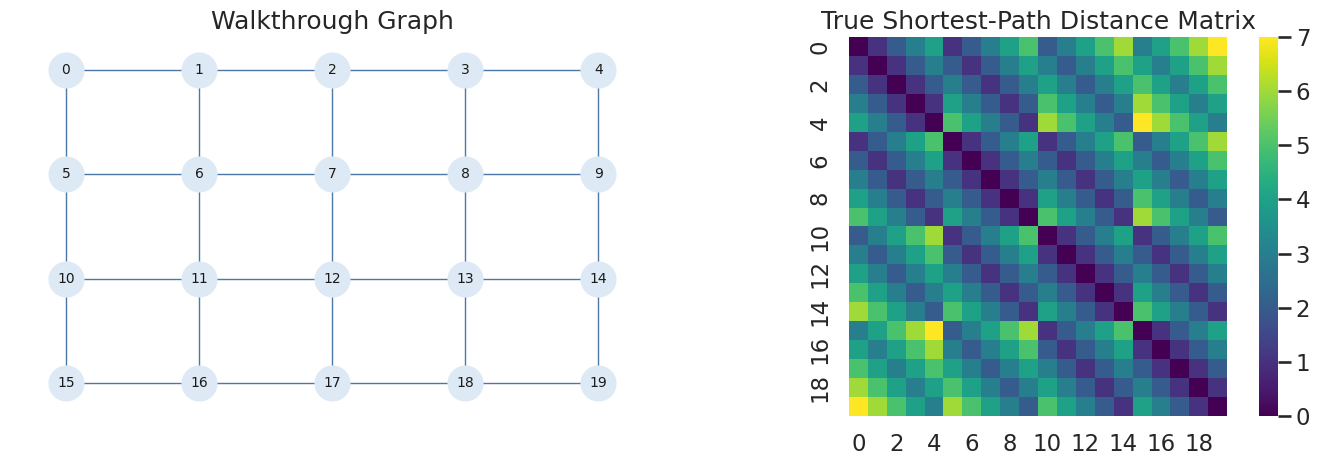

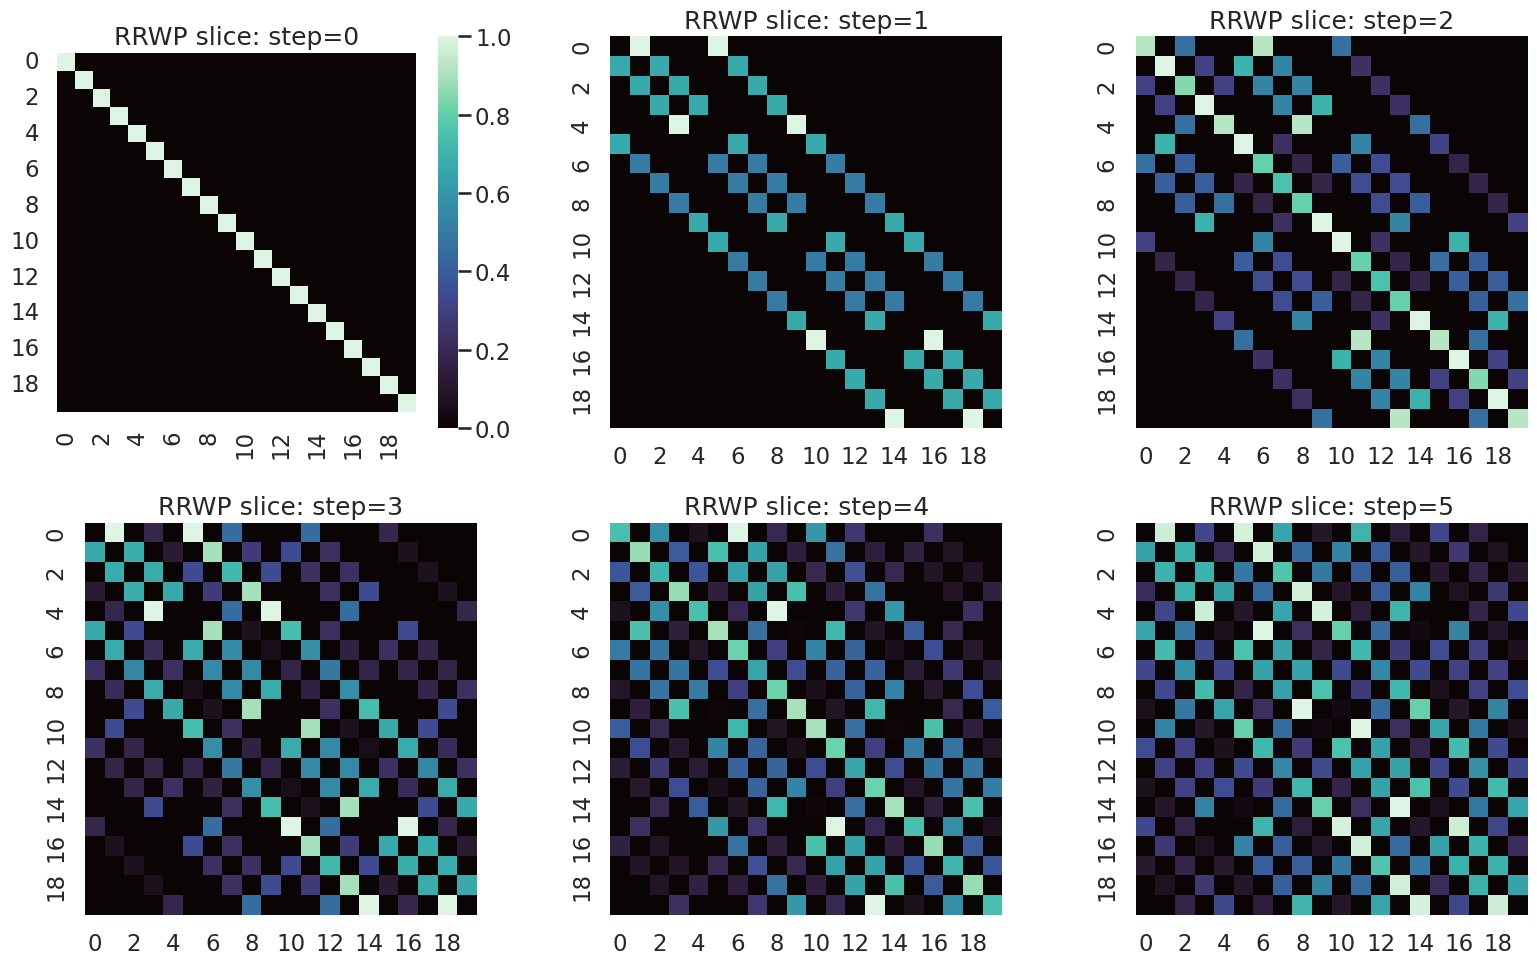

In [6]:
walk_G, walk_pos = build_walkthrough_graph()
walk_spd = compute_spd_matrix(walk_G)
walk_rrwp = compute_rrwp(walk_G, CONFIG["k_main"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
nx.draw(
    walk_G,
    pos=walk_pos,
    ax=axes[0],
    node_color="#DDEAF6",
    edge_color="#4C78A8",
    with_labels=True,
    node_size=600,
    font_size=10,
)
axes[0].set_title("Walkthrough Graph")

sns.heatmap(walk_spd, cmap="viridis", ax=axes[1], cbar=True, square=True)
axes[1].set_title("True Shortest-Path Distance Matrix")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for step, ax in enumerate(axes.flat):
    sns.heatmap(walk_rrwp[:, :, step], cmap="mako", ax=ax, cbar=step == 0, square=True)
    ax.set_title(f"RRWP slice: step={step}")
plt.tight_layout()
plt.show()

The RRWP slices can be interpreted as follows:

- **step 0** is the identity matrix, so only a node reaches itself,
- **step 1** activates immediate neighbors,
- **larger steps** encode progressively richer multihop connectivity patterns.

Nodes at different graph distances produce different RRWP signatures across walk lengths, which is the signal used by the MLP in the later sections.


## 3. Synthetic Dataset Design

Only **connected** synthetic graphs are used, so the study stays focused on expressivity rather than disconnected-node edge cases.

Families used in this notebook:

- `path`
- `cycle`
- `balanced_tree`
- `grid`
- `erdos_renyi`
- `sbm`

For every graph, **all ordered node pairs** are used as training examples. This yields a dense pair-level supervised dataset while keeping the underlying graphs small and interpretable.


In [7]:
def build_graph_records(config):
    rng = np.random.default_rng(config["seed"])
    records = []
    low, high = config["node_range"]
    for family in config["graph_families"]:
        for split, count in config["graphs_per_split"].items():
            for graph_idx in range(count):
                G = sample_connected_graph(family, rng, low, high)
                assert nx.is_connected(G), f"{family} graph is disconnected"
                rrwp = compute_rrwp(G, config["k_main"])
                assert rrwp.shape == (G.number_of_nodes(), G.number_of_nodes(), config["k_main"])
                spd = compute_spd_matrix(G)
                exact, trunc = flatten_targets(spd, config["k_main"])
                records.append(
                    {
                        "family": family,
                        "split": split,
                        "graph_idx": graph_idx,
                        "G": G,
                        "rrwp": rrwp,
                        "spd": spd,
                        "exact_spd": exact,
                        "trunc_spd": trunc,
                        "n": G.number_of_nodes(),
                        "pair_count": G.number_of_nodes() ** 2,
                    }
                )
    return records


graph_records = build_graph_records(CONFIG)
len(graph_records)

72

,family,split,nodes,ordered_pairs,class_0,class_1,class_2,class_3,class_4,class_5,class_6
0,path,train,30,900,30,58,56,54,52,50,600
1,path,train,25,625,25,48,46,44,42,40,380
2,path,train,26,676,26,50,48,46,44,42,420
3,path,train,29,841,29,56,54,52,50,48,552
4,path,train,24,576,24,46,44,42,40,38,342
5,path,train,27,729,27,52,50,48,46,44,462
6,path,train,28,784,28,54,52,50,48,46,506
7,path,train,19,361,19,36,34,32,30,28,182
8,path,val,16,256,16,30,28,26,24,22,110
9,path,val,20,400,20,38,36,34,32,30,210


,family,split,avg_nodes,avg_ordered_pairs
0,balanced_tree,test,28.000,784.000
1,balanced_tree,train,24.875,625.125
2,balanced_tree,val,27.000,738.000
3,cycle,test,20.500,420.500
4,cycle,train,22.500,530.750
5,cycle,val,24.000,592.000
6,erdos_renyi,test,25.500,652.500
7,erdos_renyi,train,26.125,691.875
8,erdos_renyi,val,23.500,564.500
9,grid,test,16.000,256.000


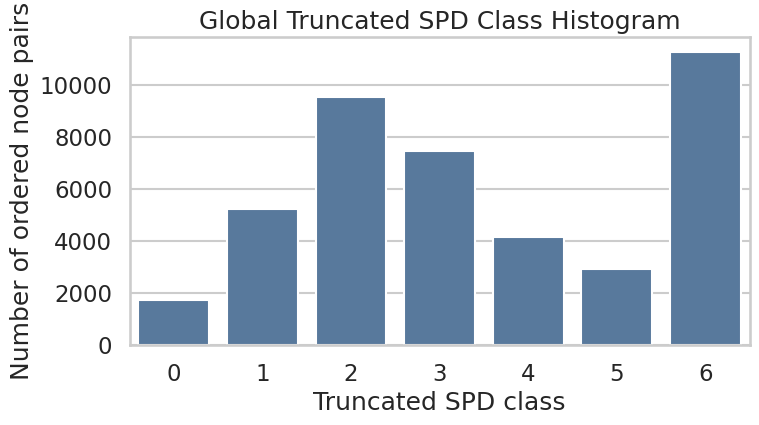

In [8]:
summary_rows = []
for rec in graph_records:
    hist = Counter(rec["trunc_spd"])
    row = {
        "family": rec["family"],
        "split": rec["split"],
        "nodes": rec["n"],
        "ordered_pairs": rec["pair_count"],
    }
    for cls in range(CONFIG["k_main"] + 1):
        row[f"class_{cls}"] = hist.get(cls, 0)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
display(summary_df.head(12))

family_split_summary = (
    summary_df.groupby(["family", "split"], as_index=False)[["nodes", "ordered_pairs"]].mean()
    .rename(columns={"nodes": "avg_nodes", "ordered_pairs": "avg_ordered_pairs"})
)
display(family_split_summary)

global_hist = Counter()
for rec in graph_records:
    global_hist.update(rec["trunc_spd"].tolist())

hist_df = pd.DataFrame(
    {"distance_class": list(range(CONFIG["k_main"] + 1)),
     "count": [global_hist.get(i, 0) for i in range(CONFIG["k_main"] + 1)]}
)

plt.figure(figsize=(8, 4))
sns.barplot(data=hist_df, x="distance_class", y="count", color="#4C78A8")
plt.title("Global Truncated SPD Class Histogram")
plt.xlabel("Truncated SPD class")
plt.ylabel("Number of ordered node pairs")
plt.show()

In [9]:
# A few direct checks so the labels are not a black box.
path_graph = nx.path_graph(7)
path_spd = compute_spd_matrix(path_graph)
path_trunc = truncate_spd(path_spd, k=4)

assert path_spd[0, 0] == 0
assert path_spd[0, 1] == 1
assert path_spd[0, 3] == 3
assert path_trunc[0, 6] == 4

print("Manual SPD checks passed on a path graph.")
print(path_trunc)

Manual SPD checks passed on a path graph.
[[0 1 2 3 4 4 4]
 [1 0 1 2 3 4 4]
 [2 1 0 1 2 3 4]
 [3 2 1 0 1 2 3]
 [4 3 2 1 0 1 2]
 [4 4 3 2 1 0 1]
 [4 4 4 3 2 1 0]]


## 4. Model: A Small Pairwise MLP

The model is intentionally simple:

- input: the RRWP feature vector for one ordered pair,
- hidden widths: `128 -> 128 -> 64`,
- activation: `GELU`,
- output: one of the `K + 1` truncated distance classes.

This setup isolates the role of the RRWP features themselves, rather than relying on a large or highly tuned model.


In [10]:
class PairMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dims, num_classes: int):
        super().__init__()
        dims = [input_dim] + list(hidden_dims)
        layers = []
        for d_in, d_out in zip(dims[:-1], dims[1:]):
            layers.append(nn.Linear(d_in, d_out))
            layers.append(nn.GELU())
        layers.append(nn.Linear(dims[-1], num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def make_dataset(records, split, feature_mode="pairwise", k=6, keep_families=None, holdout_family=None):
    xs, ys, exacts, families = [], [], [], []
    for rec in records:
        if rec["split"] != split:
            continue
        if keep_families is not None and rec["family"] not in keep_families:
            continue
        if holdout_family is not None and rec["family"] == holdout_family:
            continue

        rrwp = rec["rrwp"]
        if feature_mode == "pairwise":
            feat = get_pairwise_features(rrwp, k)
        elif feature_mode == "one_hop":
            feat = get_one_hop_features(rrwp)
        elif feature_mode == "rwse_node_only":
            feat = get_node_only_rwse_features(rrwp, k)
        else:
            raise ValueError(feature_mode)

        spd = rec["spd"]
        exact, trunc = flatten_targets(spd, k)
        xs.append(feat)
        ys.append(trunc)
        exacts.append(exact)
        families.extend([rec["family"]] * len(trunc))

    X = np.concatenate(xs, axis=0).astype(np.float32)
    y = np.concatenate(ys, axis=0).astype(np.int64)
    exact = np.concatenate(exacts, axis=0).astype(np.int64)
    return X, y, exact, np.array(families)


def make_loader(X, y, batch_size, shuffle):
    dataset = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def evaluate_model(model, X, y, exact, batch_size=8192):
    model.eval()
    preds = []
    with torch.no_grad():
        for start in range(0, len(X), batch_size):
            xb = torch.from_numpy(X[start : start + batch_size]).to(DEVICE)
            logits = model(xb)
            preds.append(logits.argmax(dim=1).cpu().numpy())
    pred = np.concatenate(preds)
    metrics = {
        "accuracy": accuracy_score(y, pred),
        "macro_f1": f1_score(y, pred, average="macro"),
        "pred": pred,
        "confusion": confusion_matrix(y, pred, labels=list(range(int(y.max()) + 1))),
    }

    bucket_rows = []
    max_bucket = int(y.max())
    for d in range(max_bucket + 1):
        if d < max_bucket:
            mask = exact == d
            bucket_name = str(d)
        else:
            mask = exact >= d
            bucket_name = f"{d}+"
        if mask.any():
            bucket_rows.append(
                {
                    "distance_bucket": bucket_name,
                    "count": int(mask.sum()),
                    "accuracy": float((pred[mask] == y[mask]).mean()),
                }
            )
    return metrics, pd.DataFrame(bucket_rows)


def train_mlp(train_X, train_y, val_X, val_y, input_dim, num_classes, config):
    model = PairMLP(input_dim=input_dim, hidden_dims=config["hidden_dims"], num_classes=num_classes).to(DEVICE)
    optimizer = torch.optim.Adam(
        model.parameters(), lr=config["learning_rate"], weight_decay=config["weight_decay"]
    )
    criterion = nn.CrossEntropyLoss()

    train_loader = make_loader(train_X, train_y, config["batch_size"], shuffle=True)
    val_loader = make_loader(val_X, val_y, config["batch_size"], shuffle=False)

    history = []
    best_state = None
    best_val = float("inf")
    patience_left = config["patience"]

    for epoch in range(1, config["max_epochs"] + 1):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)
                val_losses.append(criterion(model(xb), yb).item())

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})

        if val_loss < best_val - 1e-4:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_left = config["patience"]
        else:
            patience_left -= 1
            if patience_left == 0:
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


def run_experiment(records, config, feature_mode="pairwise", k=6, train_families=None, holdout_family=None):
    train_X, train_y, train_exact, train_family = make_dataset(
        records, "train", feature_mode=feature_mode, k=k, keep_families=train_families, holdout_family=holdout_family
    )
    val_X, val_y, val_exact, val_family = make_dataset(
        records, "val", feature_mode=feature_mode, k=k, keep_families=train_families, holdout_family=holdout_family
    )
    test_X, test_y, test_exact, test_family = make_dataset(
        records, "test", feature_mode=feature_mode, k=k, keep_families=None, holdout_family=None
    )
    if holdout_family is not None:
        mask = test_family == holdout_family
        test_X, test_y, test_exact, test_family = test_X[mask], test_y[mask], test_exact[mask], test_family[mask]

    model, history = train_mlp(
        train_X=train_X,
        train_y=train_y,
        val_X=val_X,
        val_y=val_y,
        input_dim=train_X.shape[1],
        num_classes=k + 1,
        config=config,
    )

    train_metrics, train_bucket = evaluate_model(model, train_X, train_y, train_exact)
    val_metrics, val_bucket = evaluate_model(model, val_X, val_y, val_exact)
    test_metrics, test_bucket = evaluate_model(model, test_X, test_y, test_exact)

    summary = pd.DataFrame(
        [
            {"split": "train", "accuracy": train_metrics["accuracy"], "macro_f1": train_metrics["macro_f1"]},
            {"split": "val", "accuracy": val_metrics["accuracy"], "macro_f1": val_metrics["macro_f1"]},
            {"split": "test", "accuracy": test_metrics["accuracy"], "macro_f1": test_metrics["macro_f1"]},
        ]
    )
    return {
        "model": model,
        "history": history,
        "summary": summary,
        "train_metrics": train_metrics,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "train_bucket": train_bucket,
        "val_bucket": val_bucket,
        "test_bucket": test_bucket,
    }

## 5. Core Result: Full RRWP Pair Features

The main experiment trains the model on the full pairwise RRWP vector with `K = 6`.

This directly tests the proposition in the finite synthetic setting:

- input: `P[i, j, :]` for each ordered pair,
- target: truncated SPD class in `{0, 1, 2, 3, 4, 5, 6}`.


In [11]:
main_result = run_experiment(graph_records, CONFIG, feature_mode="pairwise", k=CONFIG["k_main"])
display(main_result["summary"])

,split,accuracy,macro_f1
0,train,0.963774,0.954886
1,val,0.959378,0.944898
2,test,0.962243,0.945979


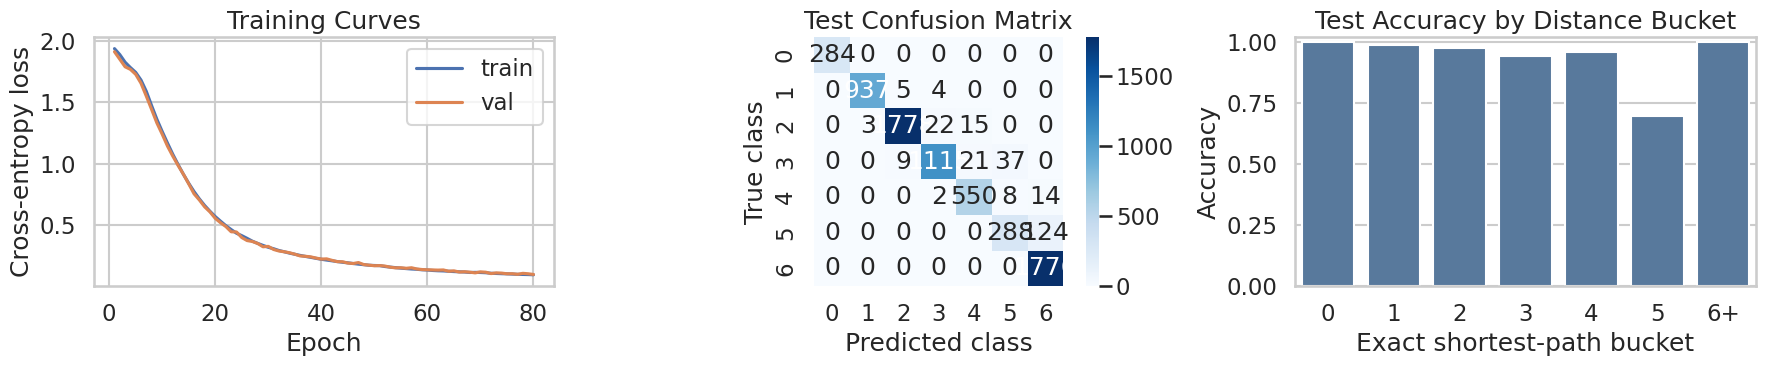

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(main_result["history"]["epoch"], main_result["history"]["train_loss"], label="train")
axes[0].plot(main_result["history"]["epoch"], main_result["history"]["val_loss"], label="val")
axes[0].set_title("Training Curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].legend()

cm = main_result["test_metrics"]["confusion"]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1], square=True)
axes[1].set_title("Test Confusion Matrix")
axes[1].set_xlabel("Predicted class")
axes[1].set_ylabel("True class")

sns.barplot(data=main_result["test_bucket"], x="distance_bucket", y="accuracy", color="#4C78A8", ax=axes[2])
axes[2].set_ylim(0, 1.02)
axes[2].set_title("Test Accuracy by Distance Bucket")
axes[2].set_xlabel("Exact shortest-path bucket")
axes[2].set_ylabel("Accuracy")

plt.tight_layout()
plt.show()

The main diagnostics to examine in this section are:

- overall accuracy and macro-F1,
- the structure of the confusion matrix,
- accuracy as a function of distance bucket,
- behavior near the truncation boundary.


## 6. Ablation A: How Many RRWP Hops Are Needed?

Proposition 3.1 links the RRWP horizon to the amount of distance information that can be recovered.

The first ablation varies only `K`:

- `K = 2`
- `K = 4`
- `K = 6`

The goal is to evaluate how the recoverable distance range changes as more walk-length information is provided.


,K,test_accuracy,test_macro_f1
0,2,1.000000,1.000000
1,4,0.984268,0.985343
2,6,0.955378,0.935989


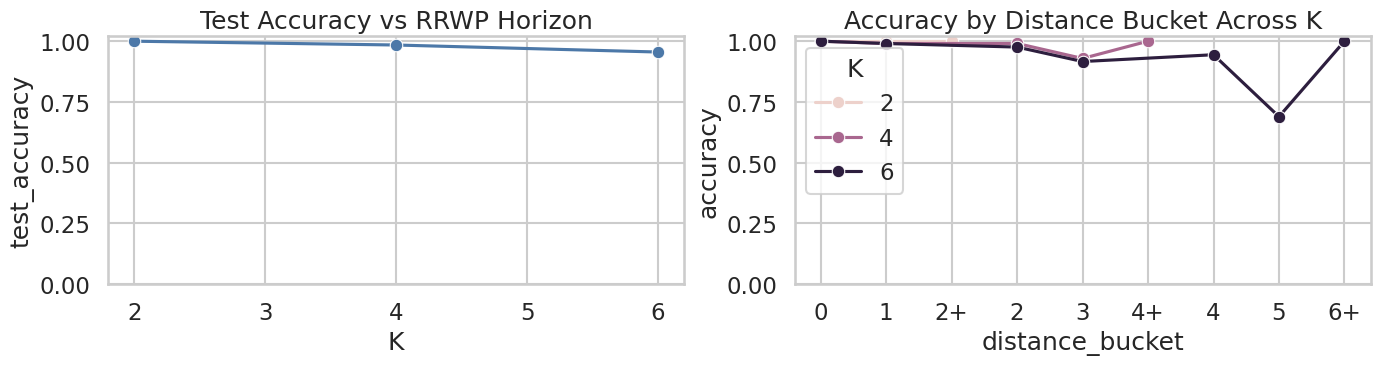

In [13]:
k_sweep_rows = []
k_sweep_bucket_rows = []
for k in CONFIG["k_sweep"]:
    result = run_experiment(graph_records, CONFIG, feature_mode="pairwise", k=k)
    test_acc = float(result["summary"].query("split == 'test'")["accuracy"].iloc[0])
    test_f1 = float(result["summary"].query("split == 'test'")["macro_f1"].iloc[0])
    k_sweep_rows.append({"K": k, "test_accuracy": test_acc, "test_macro_f1": test_f1})
    bucket_df = result["test_bucket"].copy()
    bucket_df["K"] = k
    k_sweep_bucket_rows.append(bucket_df)

k_sweep_df = pd.DataFrame(k_sweep_rows)
k_sweep_bucket_df = pd.concat(k_sweep_bucket_rows, ignore_index=True)
display(k_sweep_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.lineplot(data=k_sweep_df, x="K", y="test_accuracy", marker="o", ax=axes[0], color="#4C78A8")
axes[0].set_ylim(0, 1.02)
axes[0].set_title("Test Accuracy vs RRWP Horizon")

sns.lineplot(
    data=k_sweep_bucket_df,
    x="distance_bucket",
    y="accuracy",
    hue="K",
    marker="o",
    ax=axes[1],
)
axes[1].set_ylim(0, 1.02)
axes[1].set_title("Accuracy by Distance Bucket Across K")
plt.tight_layout()
plt.show()

## 7. Ablation B: Pairwise RRWP vs Weaker Feature Choices

In this section, we compare the full pairwise RRWP representation against two weaker alternatives:

1. **1-hop only**: the model receives only the step-1 random-walk probability.
2. **Node-only RWSE-style**: the model receives only diagonal self-return statistics for the source and target nodes, without an explicit pairwise relation.

These comparisons clarify whether the pairwise RRWP representation is responsible for the main gains.


,feature_mode,accuracy,macro_f1
0,Full pairwise RRWP,0.958381,0.940479
2,Node-only RWSE-style,0.448227,0.205227
1,1-hop only,0.389302,0.207729


/tmp/ipykernel_12930/2260252846.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_df, x="feature_mode", y="accuracy", ax=axes[0], palette="Blues_d")


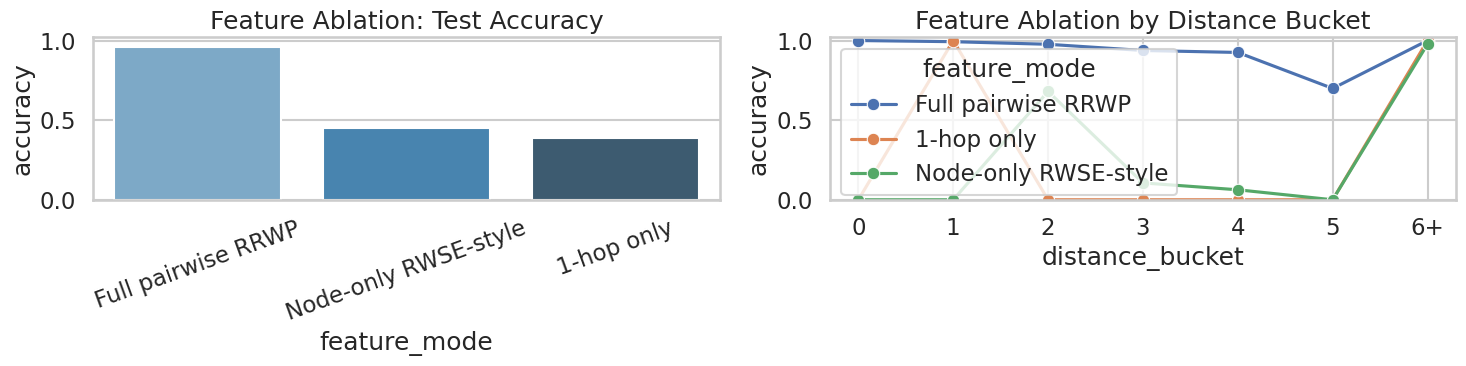

In [14]:
feature_results = []
feature_bucket_frames = []
feature_modes = {
    "Full pairwise RRWP": "pairwise",
    "1-hop only": "one_hop",
    "Node-only RWSE-style": "rwse_node_only",
}

for label, mode in feature_modes.items():
    result = run_experiment(graph_records, CONFIG, feature_mode=mode, k=CONFIG["k_main"])
    row = result["summary"].query("split == 'test'").iloc[0].to_dict()
    row["feature_mode"] = label
    feature_results.append(row)
    bucket_df = result["test_bucket"].copy()
    bucket_df["feature_mode"] = label
    feature_bucket_frames.append(bucket_df)

feature_df = pd.DataFrame(feature_results)[["feature_mode", "accuracy", "macro_f1"]].sort_values(
    "accuracy", ascending=False
)
display(feature_df)

feature_bucket_df = pd.concat(feature_bucket_frames, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.barplot(data=feature_df, x="feature_mode", y="accuracy", ax=axes[0], palette="Blues_d")
axes[0].set_ylim(0, 1.02)
axes[0].set_title("Feature Ablation: Test Accuracy")
axes[0].tick_params(axis="x", rotation=20)

sns.lineplot(
    data=feature_bucket_df,
    x="distance_bucket",
    y="accuracy",
    hue="feature_mode",
    marker="o",
    ax=axes[1],
)
axes[1].set_ylim(0, 1.02)
axes[1].set_title("Feature Ablation by Distance Bucket")
plt.tight_layout()
plt.show()

full_acc = float(feature_df.query("feature_mode == 'Full pairwise RRWP'")["accuracy"].iloc[0])
one_hop_acc = float(feature_df.query("feature_mode == '1-hop only'")["accuracy"].iloc[0])
node_only_acc = float(feature_df.query("feature_mode == 'Node-only RWSE-style'")["accuracy"].iloc[0])
assert full_acc > one_hop_acc, "The full RRWP model should outperform the 1-hop baseline."
assert full_acc > node_only_acc, "The full RRWP model should outperform the node-only baseline."

## 8. Ablation C: Family Generalization

Here we study whether the learned RRWP-to-distance mapping transfers across graph families.

Two structurally different families are held out:

- `grid`
- `sbm`

For each holdout experiment, training uses every other family and evaluation is performed only on the held-out family.


,held_out_family,accuracy,macro_f1
0,grid,1.00000,1.000000
1,sbm,0.87082,0.620621


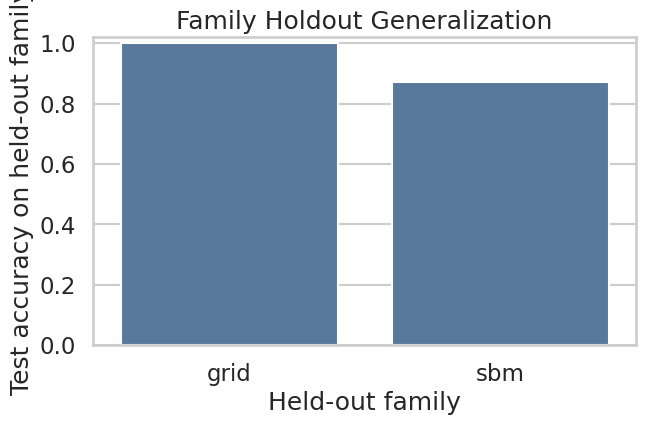

In [15]:
holdout_rows = []
for holdout_family in CONFIG["family_holdouts"]:
    train_families = [f for f in CONFIG["graph_families"] if f != holdout_family]
    result = run_experiment(
        graph_records,
        CONFIG,
        feature_mode="pairwise",
        k=CONFIG["k_main"],
        train_families=train_families,
        holdout_family=holdout_family,
    )
    row = result["summary"].query("split == 'test'").iloc[0].to_dict()
    row["held_out_family"] = holdout_family
    holdout_rows.append(row)

holdout_df = pd.DataFrame(holdout_rows)[["held_out_family", "accuracy", "macro_f1"]]
display(holdout_df)

plt.figure(figsize=(7, 4))
sns.barplot(data=holdout_df, x="held_out_family", y="accuracy", color="#4C78A8")
plt.ylim(0, 1.02)
plt.title("Family Holdout Generalization")
plt.ylabel("Test accuracy on held-out family")
plt.xlabel("Held-out family")
plt.show()

In [18]:
final_summary = pd.DataFrame(
    [
        {
            "experiment": "Main RRWP -> SPD",
            "test_accuracy": float(main_result["summary"].query("split == 'test'")["accuracy"].iloc[0]),
            "test_macro_f1": float(main_result["summary"].query("split == 'test'")["macro_f1"].iloc[0]),
        },
        {
            "experiment": "Best feature baseline",
            "test_accuracy": float(feature_df.query("feature_mode != 'Full pairwise RRWP'")["accuracy"].max()),
            "test_macro_f1": float(
                feature_df.sort_values("accuracy", ascending=False).query("feature_mode != 'Full pairwise RRWP'").iloc[0]["macro_f1"]
            ),
        },
    ]
)
display(final_summary)

print("Thank You!")

,experiment,test_accuracy,test_macro_f1
0,Main RRWP -> SPD,0.962243,0.945979
1,Best feature baseline,0.448227,0.205227


Thank You!
